[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/toche7/SlideAdvanceDSBDI/blob/main/notebook-05-06-intermediate-ml-morning.ipynb)

**Open this notebook in Google Colab**

กดปุ่มด้านบนเพื่อเปิด notebook นี้จาก GitHub เข้า Colab ได้ทันที

# BDAT501 – Module 05-06 (Morning)
## Intermediate Machine Learning: Model Selection and Evaluation

**ผู้สอน:** ผศ.ดร. ทวีศักดิ์ สมานชื่น  
คณะวิศวกรรมศาสตร์ · มหาวิทยาลัยมหิดล

---

### วัตถุประสงค์การเรียนรู้
1. แยกประเภทปัญหา Supervised / Unsupervised Learning ได้
2. สร้าง baseline และโมเดลหลักสำหรับ classification บนข้อมูลจริง
3. เลือกใช้ metric และ cross-validation ที่เหมาะกับโจทย์ธุรกิจ
4. รับมือข้อมูลไม่สมดุลด้วย class weight และ threshold tuning
5. สรุปเหตุผลการเลือกโมเดลในรูปแบบที่สื่อสารกับทีมได้

---

### Dataset
**IBM Telco Customer Churn** จาก Kaggle  
- 7,043 customers | Target: `Churn` (Yes / No) | Binary classification  
- ดาวน์โหลด: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---
## 0 · Setup – Import Libraries

In [ ]:
# ติดตั้ง dependency ที่อาจยังไม่มีใน environment
# !pip install xgboost lightgbm --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1 · Problem Framing: Customer Churn Prediction

| | |
|---|---|
| **อินพุต** | พฤติกรรมลูกค้า, ประวัติการใช้งาน, แพ็กเกจ |
| **เอาต์พุต** | ลูกค้าจะ churn หรือไม่ (Yes / No) |
| **ประเภทปัญหา** | Supervised Binary Classification |

---
## 2 · Load & Explore Data

In [3]:
# ---- โหลดข้อมูล ----
# วิธีที่ 1: อัปโหลดไฟล์ใน Colab
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(next(iter(uploaded)))

# วิธีที่ 2: ใส่ path โดยตรง (สำหรับ local)
# df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# วิธีที่ 3: ดาวน์โหลดตรงจาก URL (GitHub mirror)
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(URL)
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# ข้อมูลเบื้องต้น
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# ตรวจ missing values
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# สถิติพื้นฐาน
df.describe(include='all')

Missing values per column:
Series([], dtype: int64)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class ratio (Churn=Yes): 26.5%


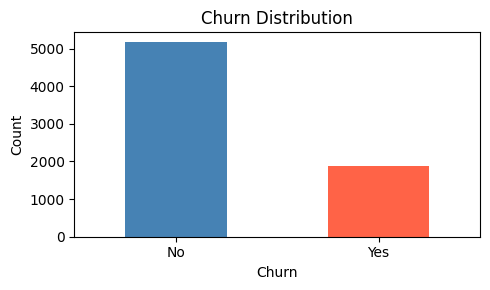

In [6]:
# Class distribution
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f'\nClass ratio (Churn=Yes): {churn_counts["Yes"]/len(df)*100:.1f}%')

churn_counts.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(5, 3), title='Churn Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 3 · Data Preprocessing

In [7]:
df_clean = df.copy()

# แปลง TotalCharges เป็น numeric (มี whitespace แฝงในข้อมูล)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# แปลง target เป็น binary
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# ลบคอลัมน์ที่ไม่ใช้ (ID)
df_clean.drop(columns=['customerID'], inplace=True)

# One-hot encoding สำหรับตัวแปร categorical
df_encoded = pd.get_dummies(df_clean, drop_first=True)

print(f'Features after encoding: {df_encoded.shape[1] - 1}')
df_encoded.head(3)

Features after encoding: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [8]:
# แบ่ง X, y และ Train/Test split
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean()*100:.1f}% | Test churn rate: {y_test.mean()*100:.1f}%')

Train: 5634 samples | Test: 1409 samples
Train churn rate: 26.5% | Test churn rate: 26.5%


---
## 4 · Model 1 – Baseline: Logistic Regression

สมการหลัก:
$$P(y=1 \mid x) = \sigma(w^T x + b), \quad \sigma(z) = \frac{1}{1+e^{-z}}$$

เหตุผลที่เริ่มจาก Logistic Regression:
- เทรนเร็ว ตีความ coefficient ได้ผ่าน odds ratio
- เป็น baseline ที่โปร่งใสก่อน explore โมเดลที่ซับซ้อนกว่า

In [9]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



---
## 5 · Model 2 – Random Forest

กลไกสำคัญ:
1. **Bootstrap sampling** – แต่ละต้นเรียนจากข้อมูลสุ่มแบบใส่คืน
2. **Feature randomness** – แต่ละ split ใช้แค่ `sqrt(n_features)` feature
3. **Majority vote** – รวมผลจากหลายต้น → ลด variance

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.85      1035
       Churn       0.58      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



---
## 6 · Model 3 – XGBoost (Optional / Advanced)

Gradient Boosting ต่อเนื่อง:
$$\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + \eta f_t(x_i)$$

In [11]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=1.0,
    reg_alpha=0.0, scale_pos_weight=2.5,
    random_state=RANDOM_STATE, n_jobs=-1,
    verbosity=0, eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

=== XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1035
       Churn       0.54      0.67      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.76      0.77      1409



---
## 7 · Model 4 – LightGBM (Optional / Advanced)

ข้อดีหลักเมื่อเทียบ XGBoost:
- **Leaf-wise growth** (เลือก leaf ที่ลด loss มากที่สุด) → แม่นกว่าในหลายกรณี
- **GOSS** ลดข้อมูลที่ใช้เทรน 50–70% โดยยังเก็บ signal ที่ดี
- เทรนเร็วกว่า XGBoost มาก (บ่อยครั้ง 5–10×)

In [12]:
lgb = LGBMClassifier(
    n_estimators=300, max_depth=7,
    learning_rate=0.1, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1,
    verbose=-1
)

lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

print('=== LightGBM ===')
print(classification_report(y_test, y_pred_lgb, target_names=['No Churn', 'Churn']))

=== LightGBM ===
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



---
## 8 · Evaluation Metrics เชิงทฤษฎี

จาก Confusion Matrix ที่มี **TP, TN, FP, FN**:

| Metric | สูตร | เหมาะเมื่อ |
|---|---|---|
| Accuracy | $\frac{TP+TN}{TP+TN+FP+FN}$ | คลาสสมดุล |
| Precision | $\frac{TP}{TP+FP}$ | FP แพง |
| Recall | $\frac{TP}{TP+FN}$ | FN แพง |
| F1-score | $2 \cdot \frac{P \cdot R}{P+R}$ | ต้อง balance P/R |
| ROC-AUC | พื้นที่ใต้ ROC curve | เทียบความสามารถแยกคลาส |

In [13]:
def eval_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame([
    eval_metrics('Logistic Regression', y_test, y_pred_lr,  y_prob_lr),
    eval_metrics('Random Forest',       y_test, y_pred_rf,  y_prob_rf),
    eval_metrics('XGBoost',             y_test, y_pred_xgb, y_prob_xgb),
    eval_metrics('LightGBM',            y_test, y_pred_lgb, y_prob_lgb),
])

results.set_index('Model', inplace=True)
results.style.highlight_max(axis=0, props='background-color: #d4edda; font-weight: bold')

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.739500,0.506000,0.783400,0.614900,0.841200
Random Forest,0.782100,0.579200,0.655100,0.614800,0.836400
XGBoost,0.763000,0.543500,0.668400,0.599500,0.820000
LightGBM,0.762200,0.538500,0.729900,0.619800,0.830000


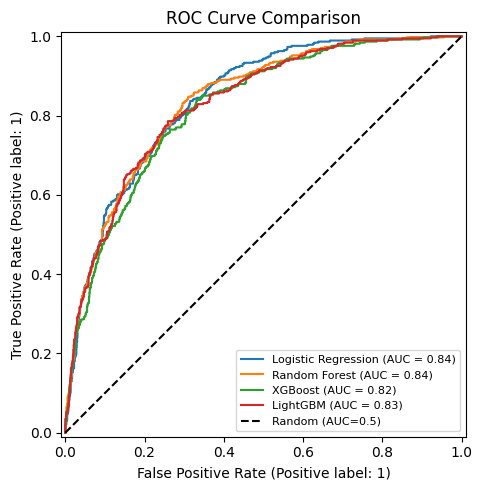

In [14]:
# ROC Curves เปรียบเทียบ
fig, ax = plt.subplots(figsize=(7, 5))

for name, prob in [
    ('Logistic Regression', y_prob_lr),
    ('Random Forest',       y_prob_rf),
    ('XGBoost',             y_prob_xgb),
    ('LightGBM',            y_prob_lgb),
]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix สำหรับโมเดลที่ดีที่สุด (Random Forest)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['No Churn', 'Churn']
    ).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

---
## 9 · Cross-Validation

ทำ **5-fold stratified CV** เพื่อประเมินความเสถียรของโมเดล  
ค่าที่รายงาน: mean ± std ของแต่ละ metric

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ['f1', 'recall', 'precision', 'roc_auc']

cv_results = {}
for name, model in [
    ('Logistic Regression', lr_pipe),
    ('Random Forest',       rf),
    ('XGBoost',             xgb),
    ('LightGBM',            lgb),
]:
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    cv_results[name] = {
        metric: f"{scores[f'test_{metric}'].mean():.4f} ± {scores[f'test_{metric}'].std():.4f}"
        for metric in SCORING
    }

pd.DataFrame(cv_results).T

,f1,recall,precision,roc_auc
Logistic Regression,0.6283 ± 0.0228,0.8007 ± 0.0357,0.5172 ± 0.0187,0.8460 ± 0.0124
Random Forest,0.6226 ± 0.0266,0.6428 ± 0.0303,0.6043 ± 0.0301,0.8396 ± 0.0106
XGBoost,0.5952 ± 0.0185,0.6341 ± 0.0239,0.5610 ± 0.0172,0.8223 ± 0.0089
LightGBM,0.6197 ± 0.0177,0.7030 ± 0.0283,0.5543 ± 0.0134,0.8309 ± 0.0087


---
## 10 · Imbalanced Data: Threshold Tuning

Default threshold = 0.5 อาจไม่เหมาะสำหรับข้อมูล imbalanced  
เราสามารถ **เลื่อน threshold** เพื่อปรับ trade-off ระหว่าง Precision และ Recall

> คำถามสำคัญ: ในโจทย์ churn **FN แพงกว่า FP หรือไม่?**  
> ถ้าตอบว่าใช่ → ควรลด threshold เพื่อเพิ่ม Recall

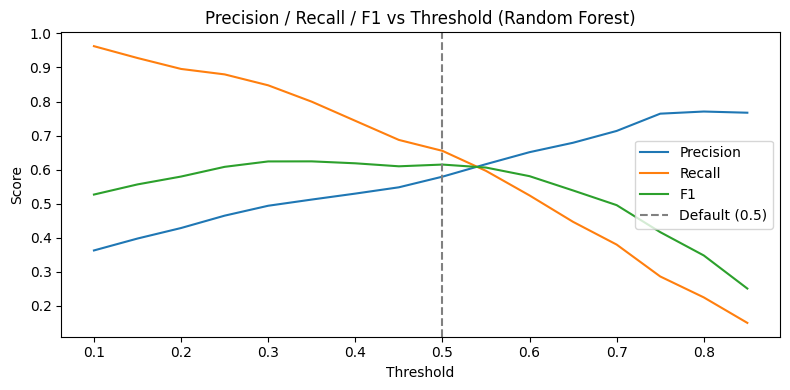

In [16]:
thresholds = np.arange(0.1, 0.9, 0.05)
records = []

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    records.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred_t, zero_division=0), 4),
    })

thresh_df = pd.DataFrame(records).set_index('Threshold')

thresh_df.plot(figsize=(8, 4), title='Precision / Recall / F1 vs Threshold (Random Forest)')
plt.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# เลือก threshold ที่ให้ F1 สูงสุด
best_row = thresh_df['F1'].idxmax()
print(f'Best threshold by F1: {best_row}')
thresh_df.loc[[best_row]]

Best threshold by F1: 0.35


,Precision,Recall,F1
Threshold,,,
0.35,0.512,0.7995,0.6242


---
## 11 · Feature Importance (Random Forest)

แสดง feature ที่มีผลต่อการตัดสินใจมากที่สุด (top 15)

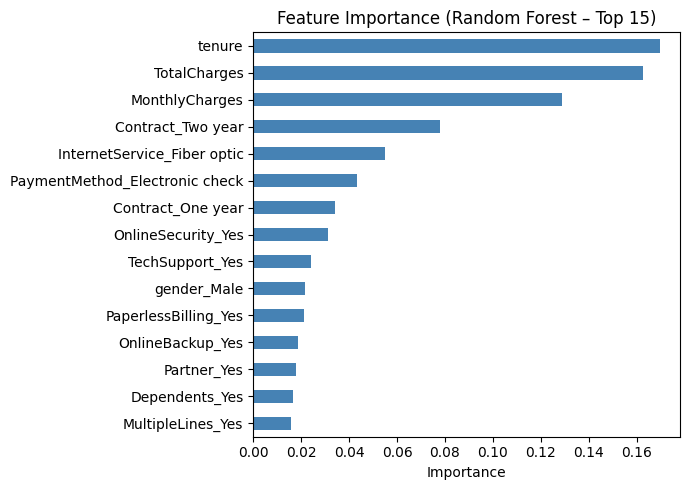

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=True).tail(15)

top15.plot(kind='barh', figsize=(7, 5), color='steelblue',
           title='Feature Importance (Random Forest – Top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## 12 · Model Card (Workshop Deliverable)

**แก้ไขส่วนนี้ตามผลการทดลองของกลุ่มคุณ**

In [19]:
model_card = {
    'Problem':          'Customer Churn Prediction (Binary Classification)',
    'Dataset':          'IBM Telco Customer Churn – 7,043 customers',
    'Candidate Models': 'Logistic Regression, Random Forest, XGBoost, LightGBM',
    'Main Metric':      'F1-score (Churn class) — เพราะ dataset imbalanced และ FN มีต้นทุนสูง',
    'Validation':       '5-fold Stratified CV + hold-out test set (20%)',
    'Selected Model':   '--- ระบุที่นี่ ---',
    'Reason':           '--- อธิบายเหตุผลเชิงธุรกิจ 3-4 บรรทัด ---',
}

pd.Series(model_card).rename('Value').to_frame()

,Value
Problem,Customer Churn Prediction (Binary Classification)
Dataset,"IBM Telco Customer Churn – 7,043 customers"
Candidate Models,"Logistic Regression, Random Forest, XGBoost, L..."
Main Metric,F1-score (Churn class) — เพราะ dataset imbalan...
Validation,5-fold Stratified CV + hold-out test set (20%)
Selected Model,--- ระบุที่นี่ ---
Reason,--- อธิบายเหตุผลเชิงธุรกิจ 3-4 บรรทัด ---


---
## สรุปภาคเช้า

1. **Problem framing** ก่อนเสมอ — เริ่มจากโจทย์ธุรกิจ ไม่ใช่โมเดล
2. **Baseline ก่อน** — Logistic Regression เป็นจุดอ้างอิงที่ตีความได้
3. **Cross-validation** สำคัญกว่าผล test set ครั้งเดียว
4. **Metric ต้องตรงกับต้นทุน** — ถ้า FN แพง ให้ focus Recall / F1
5. **Threshold tuning** ช่วยได้โดยไม่ต้องเปลี่ยนโมเดล

---
*BDAT501 Data Science Fundamentals · คณะวิศวกรรมศาสตร์ มหาวิทยาลัยมหิดล*